# Homework: Sentiment Steering and Sparse Autoencoders

This assignment explores two mechanistic interpretability techniques:

1. Sentiment steering via activation addition. 
2. Sparse autoencoder on model activations. 

In [1]:
# !pip install -q torch matplotlib transformer_lens transformers datasets 

In [2]:
import torch
from transformer_lens import HookedTransformer
import numpy as np

model = HookedTransformer.from_pretrained('gpt2')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (h

## Part 1 – Sentiment Steering via residual (3 points)

Your task is to steer model into good/bad generations and see the results.

In [3]:
from typing import List

# This is enough to steer! You may experiment with dataset as you want
positive_sentences = [
    'I love this product, it works wonderfully!',
    'This is the best day I have ever had.',
    'I am feeling fantastic and everything is great.',
    'What a delightful surprise!',
    'The food was amazing and the service was excellent.'
]

negative_sentences = [
    'I hate this product, it is terrible.',
    'This is the worst day of my life.',
    'I am feeling awful and everything is bad.',
    'What a horrible experience.',
    'The food was disgusting and the service was terrible.'
]

# Function to collect average residual activations for a list of sentences
def collect_average_residuals(sent_list: List[str]):
    n_layers = model.cfg.n_layers
    d_model = model.cfg.d_model

    avgs = [torch.zeros(d_model, device=device) for _ in range(n_layers)]
    count = [0 for _ in range(n_layers)]
    for sent in sent_list:
        tokens = model.to_tokens(sent).to(device)
        _, cache = model.run_with_cache(tokens)
        for layer in range(n_layers):
            resid = cache[f"blocks.{layer}.hook_resid_pre"]  # (1, seq_len, d_model)
            avgs[layer]  += resid.sum(dim=(0, 1))
            count[layer] += resid.shape[0] * resid.shape[1]  # batch * seq_len
    # Hint: You need *residual pre hook* from each layer
    avgs = [avgs[layer] / count[layer] for layer in range(n_layers)]
    return avgs

pos_avgs = collect_average_residuals(positive_sentences)
neg_avgs = collect_average_residuals(negative_sentences)

steering_vectors = [pos - neg for pos, neg in zip(pos_avgs, neg_avgs)]
len(steering_vectors), steering_vectors[0].shape  # (n_layers, d_model)

(12, torch.Size([768]))

In [4]:
# Function to generate text with steering applied
def generate_with_steering(prompt, max_new_tokens=20, coef=0.0):
    tokens = model.to_tokens(prompt).to(device)

    # Define hooks that add the steering vector times coef at every layer
    def make_hook(layer):
        vec = steering_vectors[layer]
        def hook(v, hook):
            v += vec * coef
            return v
        return hook

    hooks = []
    for layer in range(12):
        # Hint: make hooks that add steering vector with coef to each layer
        hooks.append((f"blocks.{layer}.hook_resid_pre", make_hook(layer)))

    for _ in range(max_new_tokens):
        logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
        next_token = logits[0, -1].argmax().unsqueeze(0)
        tokens = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)

        if next_token == model.tokenizer.eos_token_id:
            break

    return model.to_string(tokens[0, 1:])

prompt = 'The movie that I watched yesterday was'
print('Neutral completion:')
print(generate_with_steering(prompt, max_new_tokens=20, coef=0.0))
print('Positive-steered completion:')
print(generate_with_steering(prompt, max_new_tokens=20, coef=0.3))
print('Negative-steered completion:')
print(generate_with_steering(prompt, max_new_tokens=20, coef=-0.3))

Neutral completion:
The movie that I watched yesterday was a bit of a disappointment. I was hoping for a more mature, more mature, more mature movie
Positive-steered completion:
The movie that I watched yesterday was a great one. I was able to watch it with my wife and we were able to enjoy it
Negative-steered completion:
The movie that I watched yesterday was a horrible movie. It was a horrible movie. It was a horrible movie. It was a horrible


You should see how this is much more effective than tinkering with attantion heads from seminar.

## Part 2 – Sparse Autoencoder on Residual Activations (4 + bonus)

This is compute intensive part and you may adjust hyperparameters to your liking. Try to get meaningful results but in the end it might be compute bound. You still can get max points.


In [5]:
from datasets import load_dataset
ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
texts = ds["text"]

texts = [t for t in texts if len(t.strip()) > 0]
dataset_sentences = texts[:] # You may want to adjust heres

print("Total lines:", len(dataset_sentences))

Total lines: 23767


In [6]:
from tqdm import tqdm 

last_layer = model.cfg.n_layers - 1
MAX_SENTENCES = len(dataset_sentences)  # My 8GB RAM GPU Capacity

activations = []
token_to_sentence = []
with torch.no_grad():
    for sent_id, sent in tqdm(enumerate(dataset_sentences)):
        tokens = model.to_tokens(sent).to(device)
        _, cache = model.run_with_cache(tokens)
        # Take the *residual stream* at the last layer
        resid = cache[f"blocks.{last_layer}.hook_resid_pre"][0]
        activations.append(resid.cpu())
        token_to_sentence.extend([sent_id] * resid.shape[1])  # store sent_id per activated token

        if len(activations) == MAX_SENTENCES:
            break

    activations = torch.cat(activations, dim=0)
    token_to_sentence = torch.tensor(token_to_sentence)
    print('Activation dataset shape:', activations.shape)

23766it [07:19, 54.07it/s]


Activation dataset shape: torch.Size([2415651, 768])


#### Your task is to use any SAE try to disentangle features from residual. In the end you will look at top sentences that activate certain features.

Classic approach is enc + relu + dec \
For loss: mse + coef * l1 on hiddden \
But feel free to experiment!

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class SAE(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.W_enc = nn.Linear(input_dim, hidden_dim)
        self.W_dec = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        x_enc = F.relu(self.W_enc(x))
        x_dec = self.W_dec(x_enc)
        return x_enc, x_dec

In [8]:
mean = activations.mean(dim=0).to(device)
std  = activations.std(dim=0).to(device)

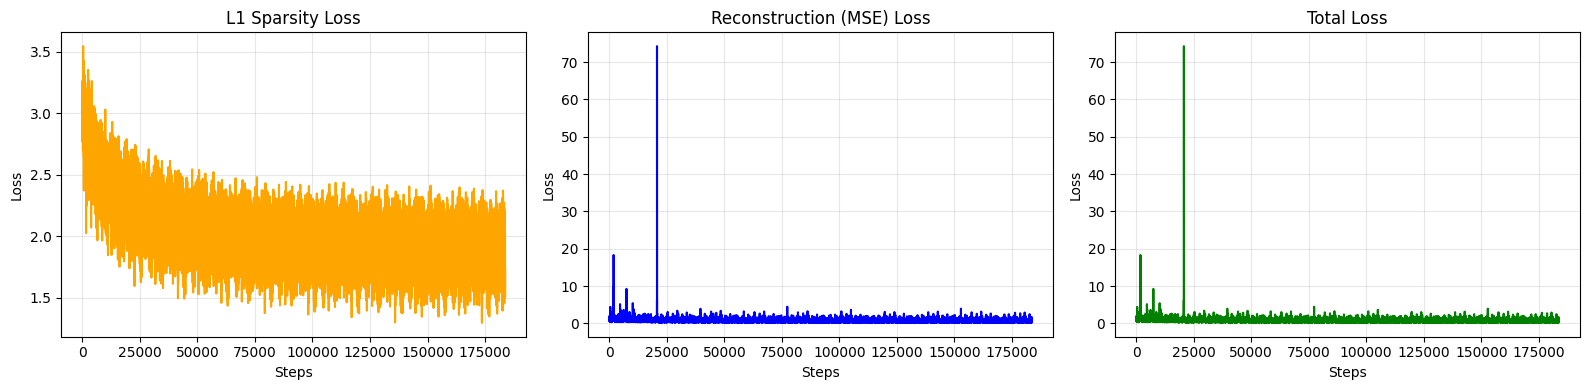

Epoch 1/10 finished. Last batch total loss: 1.012616
Epoch 2/10 finished. Last batch total loss: 0.704925
Epoch 3/10 finished. Last batch total loss: 0.716895
Epoch 4/10 finished. Last batch total loss: 0.709444
Epoch 5/10 finished. Last batch total loss: 0.733622
Epoch 6/10 finished. Last batch total loss: 0.629231
Epoch 7/10 finished. Last batch total loss: 0.695338
Epoch 8/10 finished. Last batch total loss: 0.652874
Epoch 9/10 finished. Last batch total loss: 0.633782
Epoch 10/10 finished. Last batch total loss: 0.682684


In [9]:
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output
import torch.nn.functional as F

mse_history = []
l1_history = []
total_history = []
epoch_history = []

dim_multiplier = 3
input_dim = activations.shape[1]
hidden_dim = input_dim * dim_multiplier
learning_rate = 1e-3
num_epochs = 10
batch_size = 128

alpha = 1e-3

skip_first_batches = 5000

sae = SAE(input_dim, hidden_dim).to(device)
optimizer = optim.Adam(sae.parameters(), lr=learning_rate)

dataset_size = activations.shape[0]
n_batches = dataset_size // batch_size

# -----------------
# | Training Loop |
# -----------------
for epoch in range(num_epochs):
    for batch_idx in tqdm(range(n_batches)):
        # fetch batch & normalize
        x = activations[batch_idx * batch_size : (batch_idx + 1) * batch_size].to(device)
        # x_norm = (x - mean) / std

        # sae forward
        h, x_rec = sae(x)
        # h, x_rec = sae(x_norm)

        # loss computation
        l1_loss = h.abs().mean()
        mse_loss = F.mse_loss(x_rec, x)
        # mse_loss = F.mse_loss(x_rec, x_norm)
        loss = mse_loss + alpha * l1_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        mse_history.append(mse_loss.item())
        l1_history.append(l1_loss.item())
        total_history.append(loss.item())

    clear_output(wait=True)
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 3, 1)
    plt.plot(l1_history[skip_first_batches:], label="L1 Loss", color="orange")
    plt.title("L1 Sparsity Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(mse_history[skip_first_batches:], label="MSE Loss", color="blue")
    plt.title("Reconstruction (MSE) Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(total_history[skip_first_batches:], label="Total Loss", color="green")
    plt.title("Total Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    epoch_history.append(float(loss.item()))

    for epoch, epoch_loss in enumerate(epoch_history):
        print(f"Epoch {epoch+1}/{num_epochs} finished. Last batch total loss: {epoch_loss:.6f}")

Below is some code that prints tokens that activate certain neuron the most. You are free to change it!

In [10]:
BLOCK_START = 2048
BLOCK_SIZE = batch_size * 4

In [11]:
act = activations[BLOCK_START:BLOCK_START + BLOCK_SIZE, :]
tts = token_to_sentence[BLOCK_START:BLOCK_START + BLOCK_SIZE]

In [12]:
sae.eval()
with torch.no_grad():
    # act_norm = (act - mean.cpu()) / std.cpu()
    # h, _ = sae(act_norm.to(device))
    h, _ = sae(act.to(device))
    h = h.cpu().numpy()

# For selected neuron indices, find the sentences with highest activation
selected_neurons = [0, 99, 1024]  # you can choose other indices

for neuron in selected_neurons:
    activations_neuron = h[:, neuron]
    top_idx = activations_neuron.argsort()[::-1][:5]
    print(f'Neuron {neuron}:')
    for rank, idx in enumerate(top_idx, start=1):
        sent_id = tts[idx].item()
        text = dataset_sentences[sent_id]

        toks = model.to_tokens(text)[0, 1:]
        str_toks = model.to_str_tokens(toks)

        token_positions = (tts == sent_id).nonzero(as_tuple=True)[0]
        local_pos = (token_positions == idx).nonzero(as_tuple=True)[0].item()
        cropped = "".join(str_toks[:local_pos + 1])

        print(f"Top {rank}: global token {idx}, sentence {sent_id}, local token {local_pos}")
        print(cropped)
        print()

Neuron 0:
Top 1: global token 454, sentence 3, local token 198
 It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , it received downloadable content , along with an expanded edition in November of that year . It was also adapted into manga and an original video animation series . Due to low sales of Valkyria Chronicles II , Valkyria Chronicles III was not localized , but a fan translation compatible with the game 's expanded edition was released in 2014 . Media.Vision would return to the franchise with the development of Valkyria : Azure Revolution for the PlayStation 4 . 


Top 2: global token 420, sentence 3, local token 164
 It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , it received downloadable content , along with an expanded edition in November of that year . It was also adapted into manga and an original video animation series . Due to low sales of Valkyria Chro